# CHME 212 — Midterm Makeup Exam

**Time allowed: 60 minutes (58 minutes for problem-solving, 2 minutes for submission preparation)**
**Covers: Midterm 1 & Midterm 2 material**
**Open notes, closed internet.**

---

### Instructions

1. **Submission:** Enter all answers in the provided notebook (Canvas-Files-Exam) and submit it through **Gradescope** before time is called. Late submissions will not be accepted.

2. **Electronic devices:** All personal electronic devices (phones, tablets, smartwatches) are **strictly prohibited**. Internet access and AI/code assistant tools (ChatGPT, GitHub Copilot, etc.) are **strictly prohibited**. Any violation will be treated as a violation of academic integrity.

3. **Open notes:** You may use printed or handwritten notes only.

4. **Before submitting:** Restart the kernel and run all cells to confirm your notebook runs without errors.

### Run this cell if package installation is required. If not, ignore.

In [ ]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "numpy", "matplotlib", "scipy", "-q"])

## Student Information

In [ ]:
name  = ""        # Your full name

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid, quad

---

## Part A — Fix the Code (20 pts, 5 pts each; ⏱ ~8 min)

Each snippet below contains **one bug**. Write the corrected line(s) in the answer cell provided for each question.

### A1

The following code should print **"Number is smaller than 20"**, but it raises an error. Fix it.

```python
number = 15
if number < 20:
print("Number is smaller than 20")
```

In [ ]:
number = 15
if number < 20:
print("Number is smaller than 20")

### A2

The following code should print the **last element** of the list, but it raises an error. Fix it.

```python
my_list = [1, 2, 3, 4, 5]
print(my_list[5])
```

In [ ]:
my_list = [1, 2, 3, 4, 5]
print(my_list[5])  

### A3

The following code should retrieve the temperature from the dictionary, but it prints the wrong value. Fix it.

```python
stream = {"name": "Feed", "T": 350, "P": 2.5, "phase": "vapor"}
# I want to retrieve the temperature value (350)
print(stream[1])
```

In [ ]:
stream = {"name": "Feed", "T": 350, "P": 2.5, "phase": "vapor"}
print(stream[1])

### A4

The following code should keep looping until `count` reaches 10, but it runs forever. Fix it.

```python
count = 0
while count < 10:
    print(count)
```

In [ ]:
count = 0
while count < 10:
    print(count)

### A5

The following code should compute the sum across the columns (i.e., sum each column separately). Fix it.

```python
import numpy as np
matrix = np.array([
    [1, 2, 3, 4],
    [5, 6, 7, 8],
    [9, 10, 11, 12]
])
summation = np.sum(matrix)
```

In [2]:
matrix = np.array([
    [1, 2, 3, 4],
    [5, 6, 7, 8],
    [9, 10, 11, 12]
])
summation = np.sum(matrix)
print(summation)

78


### A6

A project is organized like this:

```
reactor_tools/
    __init__.py
    kinetics.py
    thermodynamics.py
```


The following code tries to import the `kinetics` module so you can call `kinetics.rate(T)` from outside the package. Fix it.


```python
from kinetics import reactor_tools
```

In [ ]:
from kinetics import reactor_tools 
# it's not runnable, but just fix this to properly import the target function

---

## Part B — Coding Problems (80 pts)

Read each problem carefully and complete the code as instructed. Do not modify the pre-provided lines.

### B1 (30 pts; ⏱ ~18 min)

The van der Waals equation gives the pressure of a real gas:

$$P = \frac{nRT}{V - nb} - \frac{n^2 a}{V^2}$$

You are given the following CO₂ parameters and conditions:

- $n = 1$ mol, $R = 0.08206$ L·atm/(mol·K)
- $a = 3.640$ L²·atm/mol², $b = 0.04267$ L/mol
- Volume: $V = 1.5$ L (fixed)
- Temperatures to test: **[250, 300, 350, 400, 500]** K

Write a program that does **all** of the following.

**(Task 1 — 20 pts):** Compute the van der Waals pressure for each temperature, classify each result as **"Low"** (P < 10 atm), **"Medium"** (10–20 atm), or **"High"** (> 20 atm), and save all results to a file named **vdw_results.txt** in the following format:
```
T=250 K, P=xx.xxxx atm, Low
T=300 K, P=xx.xxxx atm, Medium
...
```
> **Tip:** Use a *for* loop over the temperature list and a *with open(filename, 'w')* block to write the file.

**(Task 2 — 10 pts):** For each temperature, compute the ideal gas pressure ($P_\text{ideal} = nRT/V$) alongside the van der Waals pressure, calculate the percent difference, and print the results in the following format:
```
T = 250 K, P_ideal = xx.xxxx atm, P_vdW = xx.xxxx atm, diff = xx.xx%
```


$$\% \text{ difference} = \frac{|P_\text{ideal} - P_\text{vdW}|}{P_\text{vdW}} \times 100$$


**(Task 3 - 5 pts)** Write **one or two sentences** in the markdown cell discussing what the trend in percent difference tells you about when the ideal gas approximation breaks down.


In [ ]:
n = 1
R = 0.08206
a = 3.640
b = 0.04267
V = 1.5
temperatures = [250, 300, 350, 400, 500]

# Task 1 — compute vdW pressure, classify, and write to file
# Use "line = f"T={T} K, P={P:.4f} atm, {label}" to format the output line 




In [ ]:
# Task 2 — compare ideal vs vdW and print percent difference
# Use ""T = {T} K, P_ideal = {P_ideal:.4f} atm, P_vdW = {P_vdw:.4f} atm, diff = {diff:.2f}%" to format the output line



> (Type your solution for task 3)


---

### B2 (20 pts; ⏱ ~8 min)

A combustion process requires heating nitrogen gas from 300 K to 900 K. The heat capacity $C_p$ of N₂ was measured at seven temperatures:

```python
T_data  = np.array([300,  400,  500,  600,  700,  800,  900])  # K
Cp_data = np.array([29.1, 29.2, 29.6, 30.1, 30.8, 31.4, 32.0])  # J/mol·K
```

The enthalpy change is $\Delta H = \displaystyle\int_{300}^{900} C_p(T)\,dT$.

**(Task 1 — 7 pts):** Using the trapezoidal rule on the tabulated data, compute $\Delta H$ in J/mol directly from the tabulated data.

**(Task 2 — 8 pts):** Define a Python function `Cp_fit(T)` that **evaluates** the fitted polynomial, then recompute $\Delta H$ in J/mol from the fitted curve.

**(Task 3 — 5 pts):** The two $\Delta H$ values from Task 1 and Task 2 are close but not identical. In one or two sentences, explain **why** a small difference is expected and which method you would trust more if the true $C_p(T)$ curve is smooth.

In [ ]:
import numpy as np
from scipy.integrate import trapezoid, quad

T_data  = np.array([300,  400,  500,  600,  700,  800,  900])  # K
Cp_data = np.array([29.1, 29.2, 29.6, 30.1, 30.8, 31.4, 32.0])  # J/mol·K

# Task 1 — trapezoidal integration on tabulated data
dH_trap = TODO
print(f"Task 1  ΔH (trapezoid) = {dH_trap:.3f} J/mol")

In [ ]:
# Task 2 — integrate the fitted polynomial with quad
coeffs = TODO  # linear fit with 1st degree polynomial

def Cp_fit(T):
    return TODO

dH_quad, _ = TODO  # integrate Cp_fit from 300 to 900 K
print(f"\nTask 2  ΔH (quad fit)  = {dH_quad:.3f} J/mol")
difference = TODO # Compute the absolute difference
print(f"        Difference     = {difference:.4f} J/mol")

> **(Task 3)** Type your answer here.

The trapezoidal rule approximates $C_p(T)$ as piecewise-linear between the seven data points, so it slightly underestimates the area where the curve is concave-up. If the true $C_p(T)$ is smooth, integrating the polynomial fit with quad is more accurate because the fit captures the curvature that the trapezoids miss.

---

### B3 (25 pts; ⏱ ~8 min)

A heat exchanger cools a reactor effluent stream. The outlet temperature is modeled as:

$$T_{out} = T_{in} - \frac{Q}{\dot{m} \, c_p}$$

where:
- $T_{in} = 120\,°C$ (fixed inlet temperature)
- $Q = 8000\,\text{W}$ (fixed heat removed)
- $c_p = 3.80\,\text{J g}^{-1}\,°C^{-1}$ (fixed heat capacity of the fluid)
- $\dot{m} \sim \mathcal{N}(80,\;4^2)\,\text{g/s}$ (mass flow rate, **normally distributed**)

The outlet temperature must be **no more than 95 °C** to meet process safety requirements.

**(Task 1 — 8 pts):** Compute $T_{out}$ at the mean flow rate $\dot{m} = 80\,\text{g/s}$. Check whether it meets the spec.

**(Task 2 — 17 pts):** Generate $N = 50{,}000$ samples of $\dot{m}$ and compute $T_{out}$ for each. Then find:
- Mean and standard deviation of $T_{out}$
- Fraction of runs where $T_{out} > 95\,°C$ (failure rate)

**(Task 3 — discussion):** If the standard deviation of $\dot{m}$ is reduced from 4 g/s to 2 g/s (e.g., by installing a better flow controller), would you expect the failure rate to increase, decrease, or stay the same? Explain your reasoning in 1–2 sentences as a Python comment.

In [ ]:
import numpy as np

T_in   = 120.0   # °C
Q      = 8000.0  # W
cp     = 3.80    # J/(g·°C)
spec_T = 95.0    # °C  (must be ≤ this)

# Task 1 — nominal outlet temperature at mean flow rate
mdot_mean = 80.0   # g/s
T_nominal = TODO

# Check whether T_nominal meets the spec
# If it meets the spec, write the code to print "Yes, it meets the spec."
# If not, write the code to print "No, it does not meet the spec."

In [ ]:
# Task 2 — Monte Carlo
N   = 50_000
rng = np.random.default_rng(seed=42)

# Sample mdot from normal distribution
# Do Monte Carlo to compute T_out for each sample
# Compute mean, std, and failrue rate

print(f"\nMonte Carlo results (N = {N:,}):")
print(f"  Mean T_out   = {mean_T:.2f} °C")
print(f"  Std T_out    = {std_T:.2f} °C")
print(f"  Failure rate = {fail_rate*100:.2f}%")

---

### B4 (25 pts; ⏱ ~14 min)

A mixing unit combines two feed streams and produces a single outlet stream. Each stream carries three components (A, B, C) and has its own temperature.

**Stream data:**

| | Stream 1 | Stream 2 | Outlet |
|---|---|---|---|
| Total flow (kg/h) | $F_1$ | $F_2$ | 600 |
| Mass fraction A | 0.50 | 0.10 | 0.30 |
| Mass fraction B | 0.35 | 0.55 | — |
| Mass fraction C | 0.15 | 0.35 | — |
| Temperature (°C) | 90 | 30 | $T_{out}$ |
| $c_p$ (kJ/kg·°C) | 3.2 | 4.5 | 4.0 |

The mixer operates at **steady state** with **no heat loss** to the surroundings.
Assume constant heat capacities, negligible heat of mixing, and a common reference temperature for all streams. Use the given outlet $c_p$ value directly in the energy balance.

**(Task 1 — 10 pts):** Set up and solve the **2×2 linear system** for $F_1$ and $F_2$ using the total mass balance and component A balance.

**(Task 2 — 10 pts):** Compute the outlet temperature $T_{out}$ using the energy balance equation. Think about what "steady state, no heat loss" implies: all the thermal energy carried in by the feed streams must equal the thermal energy carried out by the outlet stream. Each stream's thermal energy rate is proportional to its flow rate, heat capacity, and temperature.

**(Task 3 — discussion):** If $F_2$ increases while $F_1$ stays the same, would $T_{out}$ go **up or down**? Explain briefly in a comment.

#### **!!!Run the below cell for visualization!!!**  After running, please collapse the code cell (in JupyterLab, click the small arrow to the left of the cell, use View → Collapse Selected Code, or click the vertical bar next to the cell).

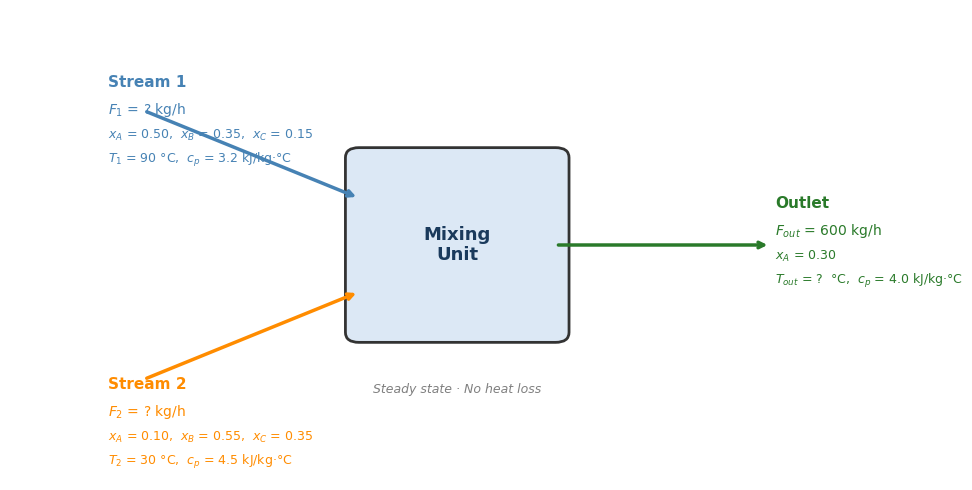

In [5]:
## !!!!!!! THIS IS NOT THE PROBLEM CODE!!!!!!!
### ONLY FOR VISUALIZATION PURPOSES — COLLAPSE THIS CELL AFTER RUNNING !!!!!!! ###
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(10, 5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 7)
ax.axis('off')

box = mpatches.FancyBboxPatch((3.9, 2.2), 2.2, 2.6,
                               boxstyle="round,pad=0.15",
                               linewidth=2, edgecolor='#333333',
                               facecolor='#dce8f5')
ax.add_patch(box)
ax.text(5.0, 3.5, 'Mixing\nUnit', ha='center', va='center',
        fontsize=13, fontweight='bold', color='#1a3a5c')

ax.annotate('', xy=(3.9, 4.2), xytext=(1.5, 5.5),
            arrowprops=dict(arrowstyle='->', color='steelblue', lw=2.5))
ax.text(1.1, 5.85, 'Stream 1', fontsize=11, fontweight='bold', color='steelblue')
ax.text(1.1, 5.45, '$F_1$ = ? kg/h', fontsize=10, color='steelblue')
ax.text(1.1, 5.08, '$x_A$ = 0.50,  $x_B$ = 0.35,  $x_C$ = 0.15', fontsize=9, color='steelblue')
ax.text(1.1, 4.72, '$T_1$ = 90 °C,  $c_p$ = 3.2 kJ/kg·°C', fontsize=9, color='steelblue')

ax.annotate('', xy=(3.9, 2.8), xytext=(1.5, 1.5),
            arrowprops=dict(arrowstyle='->', color='darkorange', lw=2.5))
ax.text(1.1, 1.35, 'Stream 2', fontsize=11, fontweight='bold', color='darkorange')
ax.text(1.1, 0.95, '$F_2$ = ? kg/h', fontsize=10, color='darkorange')
ax.text(1.1, 0.58, '$x_A$ = 0.10,  $x_B$ = 0.55,  $x_C$ = 0.35', fontsize=9, color='darkorange')
ax.text(1.1, 0.22, '$T_2$ = 30 °C,  $c_p$ = 4.5 kJ/kg·°C', fontsize=9, color='darkorange')

ax.annotate('', xy=(8.5, 3.5), xytext=(6.1, 3.5),
            arrowprops=dict(arrowstyle='->', color='#2a7a2a', lw=2.5))
ax.text(8.55, 4.05, 'Outlet', fontsize=11, fontweight='bold', color='#2a7a2a')
ax.text(8.55, 3.65, '$F_{out}$ = 600 kg/h', fontsize=10, color='#2a7a2a')
ax.text(8.55, 3.28, '$x_A$ = 0.30', fontsize=9, color='#2a7a2a')
ax.text(8.55, 2.92, '$T_{out}$ = ?  °C,  $c_p$ = 4.0 kJ/kg·°C', fontsize=9, color='#2a7a2a')

ax.text(5.0, 1.3, 'Steady state · No heat loss', ha='center', fontsize=9,
        color='gray', style='italic')

plt.tight_layout()
plt.show()
## !!!!!!! THIS IS NOT THE PROBLEM CODE!!!!!!!
### ONLY FOR VISUALIZATION PURPOSES — COLLAPSE THIS CELL AFTER RUNNING !!!!!!! ###

In [ ]:
import numpy as np

# Known stream properties
F_out  = 600.0   # kg/h
xA_out = 0.30    # outlet mass fraction of A

cp1, T1 = 3.2, 90.0   # kJ/(kg·°C), °C
cp2, T2 = 4.5, 30.0
cp_out  = 4.0          # kJ/(kg·°C)

# Task 1 — solve 2×2 system for F1 and F2
# Compute F1 and F2 using mass balances and linear algebra
# It's okay to derive the answer by your hand

print(f"F1 = {F1:.2f} kg/h")
print(f"F2 = {F2:.2f} kg/h")
print(f"Check: F1 + F2 = {F1+F2:.2f} kg/h  (expected {F_out})")



In [ ]:
# Task 2 — Outlet temperature from energy balance
# Derive the formula for T_out from the energy balance and compute it


print(f"\nOutlet temperature T_out = {T_out:.2f} °C")

> **(Task 3)** Type your answer here.
